Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from sklearn.feature_selection import VarianceThreshold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# **Multiclasse**

In [ ]:
dfSpyware = pd.read_csv("dataset_spyware_float32.csv")

In [ ]:
X = dfSpyware.drop(columns=["Category"])
y = dfSpyware["Category"]

X = X.select_dtypes(include=[np.number])

In [ ]:
print("Shape:", dfSpyware.shape)

print("\nNúmero de classes:")
print(y.nunique())

print("\nDistribuição das classes:")
print(y.value_counts())

Shape: (12026, 56)

Número de classes:
6

Distribuição das classes:
Category
Transponder    2410
Gator          2200
Benign         2004
180Solution    2002
CWS            2000
TIBS           1410
Name: count, dtype: int64


Distribuição das classes

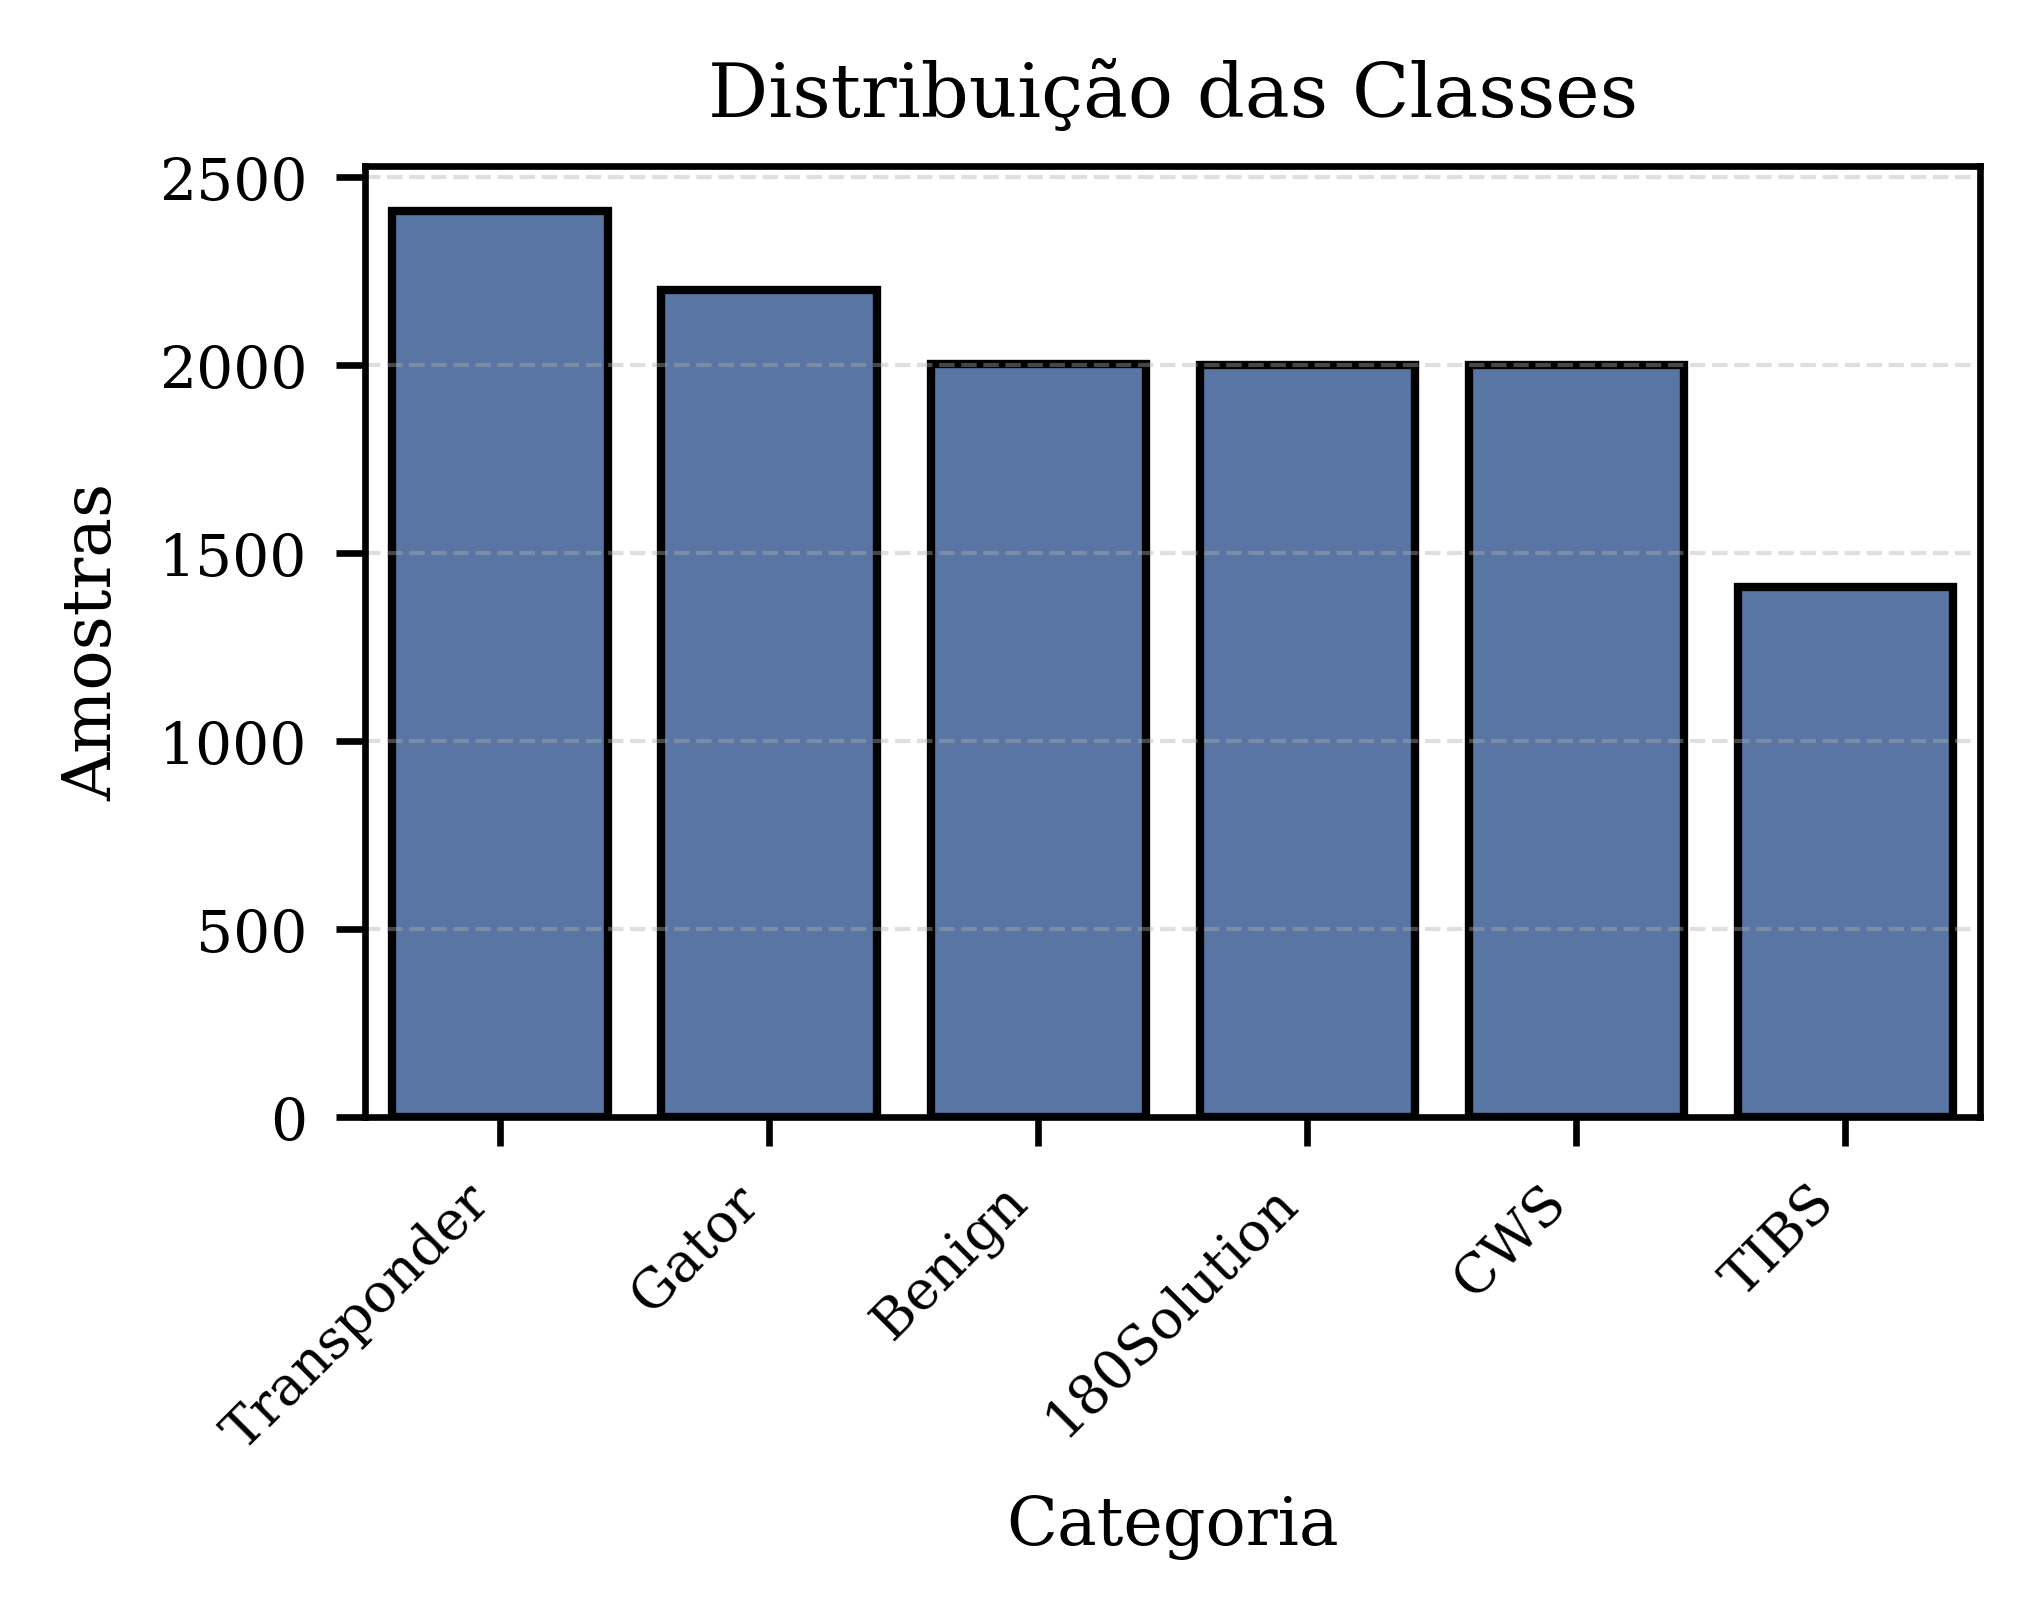

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 7,
    "figure.dpi": 600
})

fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=600)

sns.countplot(
    data=dfSpyware,
    x="Category",
    order=y.value_counts().index,
    color="#4C72B0",
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribuição das Classes", pad=6)
ax.set_xlabel("Categoria")
ax.set_ylabel("Amostras")


plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figura_01_Distribuicao_Classes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Média agregada

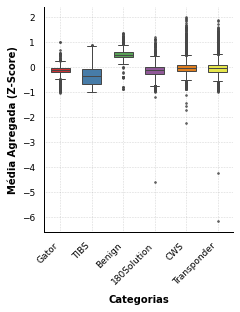

In [ ]:

dfSpyware = pd.read_csv("dataset_spyware_float32.csv")

X = dfSpyware.drop(columns=['Category'])
Y = dfSpyware['Category']

classes_unicas = Y.unique()
num_classes = len(classes_unicas)

# Normalização (Z-Score)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Agregação Estatística
df_vis = pd.DataFrame({
    'Score_Medio_Features': X_scaled.mean(axis=1),
    'Class': Y.values
})



sns.set_theme(style="whitegrid")
plt.figure(figsize=(3.5, 4.5))

palette = sns.color_palette("Set1", n_colors=num_classes)

# Plot do Boxplot
ax = sns.boxplot(
    data=df_vis,
    x='Class',
    y='Score_Medio_Features',
    palette=palette,
    dodge=False,
    width=0.6,
    fliersize=1.5,
    linewidth=1.0,
    hue='Class',
    legend=False  # Oculta legenda lateral (nomes já estão no eixo X)
)


font_labels = {'color': 'black', 'fontsize': 10, 'weight': 'bold'}
font_ticks = {'color': 'black', 'fontsize': 9}


plt.xlabel('Categorias', fontdict=font_labels, labelpad=8)
plt.ylabel('Média Agregada (Z-Score)', fontdict=font_labels)


plt.xticks(rotation=45, ha='right', **font_ticks)
plt.yticks(**font_ticks)


for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.tick_params(colors='black', labelsize=9)


ax.grid(
    visible=True,
    linestyle=':',
    linewidth=0.6,
    color='gray',
    alpha=0.5
)

sns.despine(top=True, right=True)

plt.tight_layout()

plt.savefig(
    "IEEE_Boxplot_Consolidado.png",
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

Features com maior variância

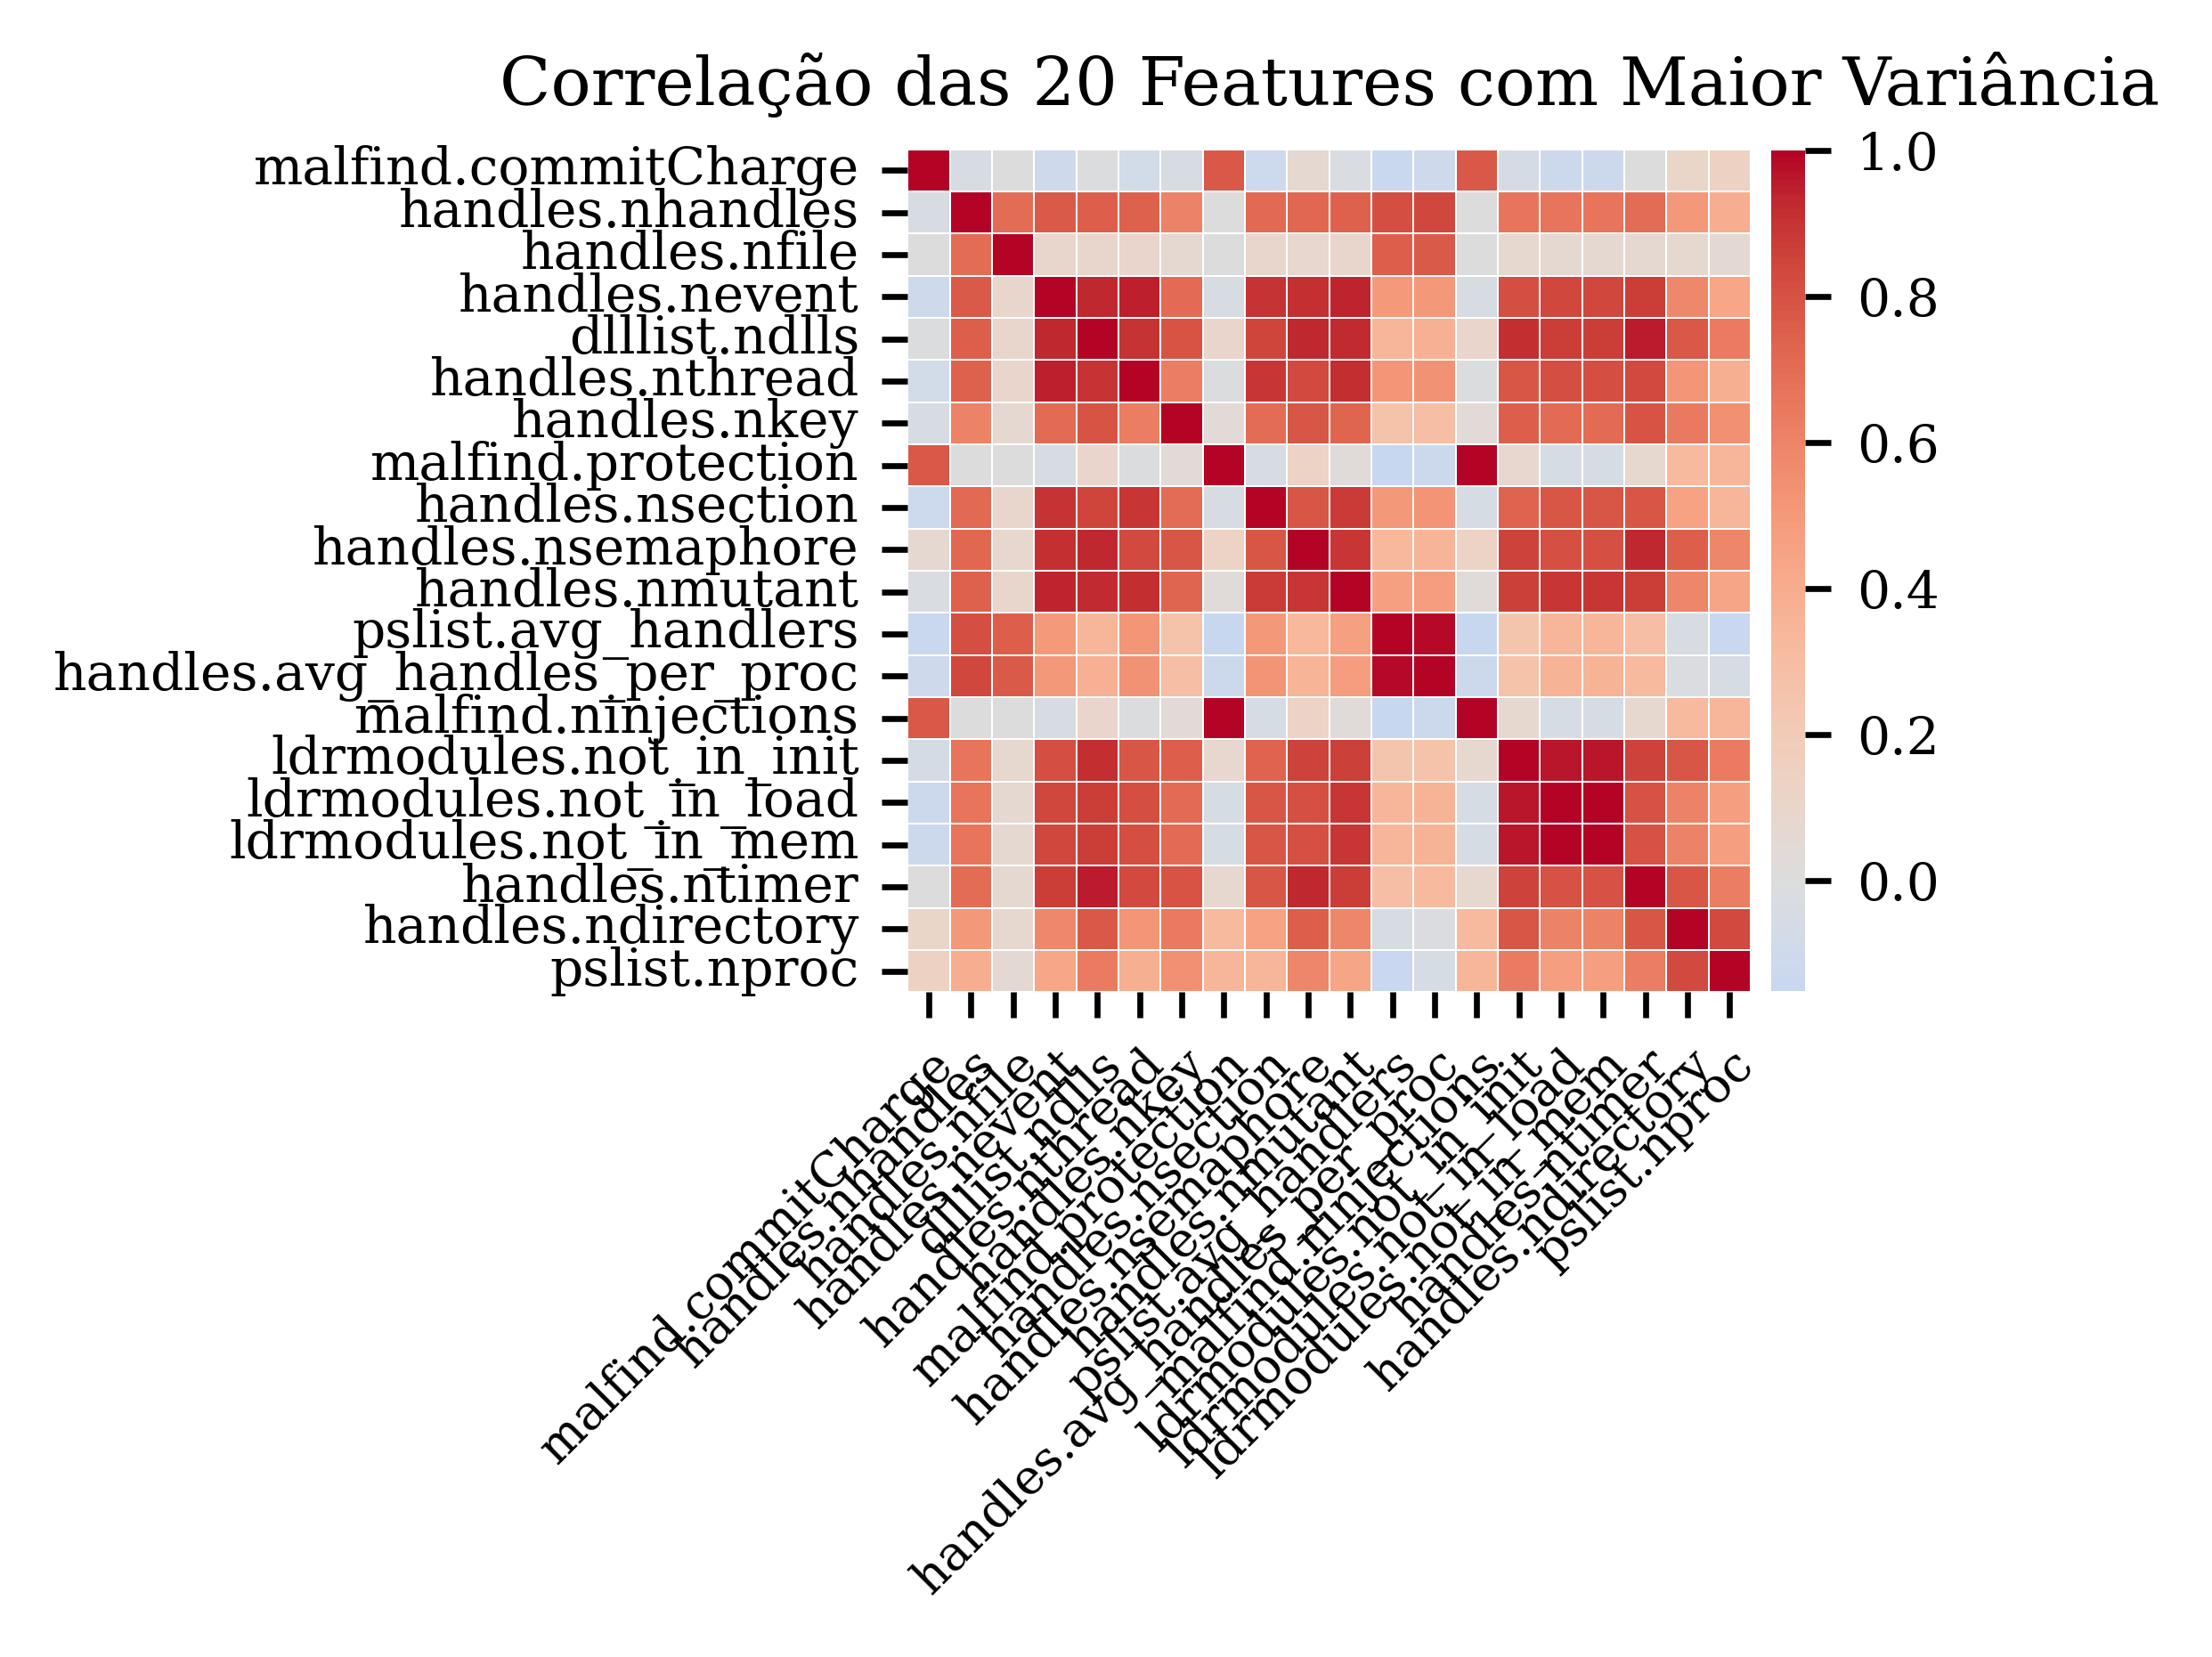

In [ ]:
variancias = X.var()
top_features = variancias.nlargest(20).index
corr = X[top_features].corr()

fig, ax = plt.subplots(figsize=(3.8, 3.6), dpi=600)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={
        "shrink": 0.7,
        "aspect": 25,
        "pad": 0.02
    },
    ax=ax
)

ax.set_title("Correlação das 20 Features com Maior Variância", pad=6)

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(rotation=0)

ax.tick_params(axis='x', pad=3)
ax.tick_params(axis='y', pad=3)

plt.tight_layout()

plt.savefig(
    "Figura_Correlacao_Features.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Perfil médio

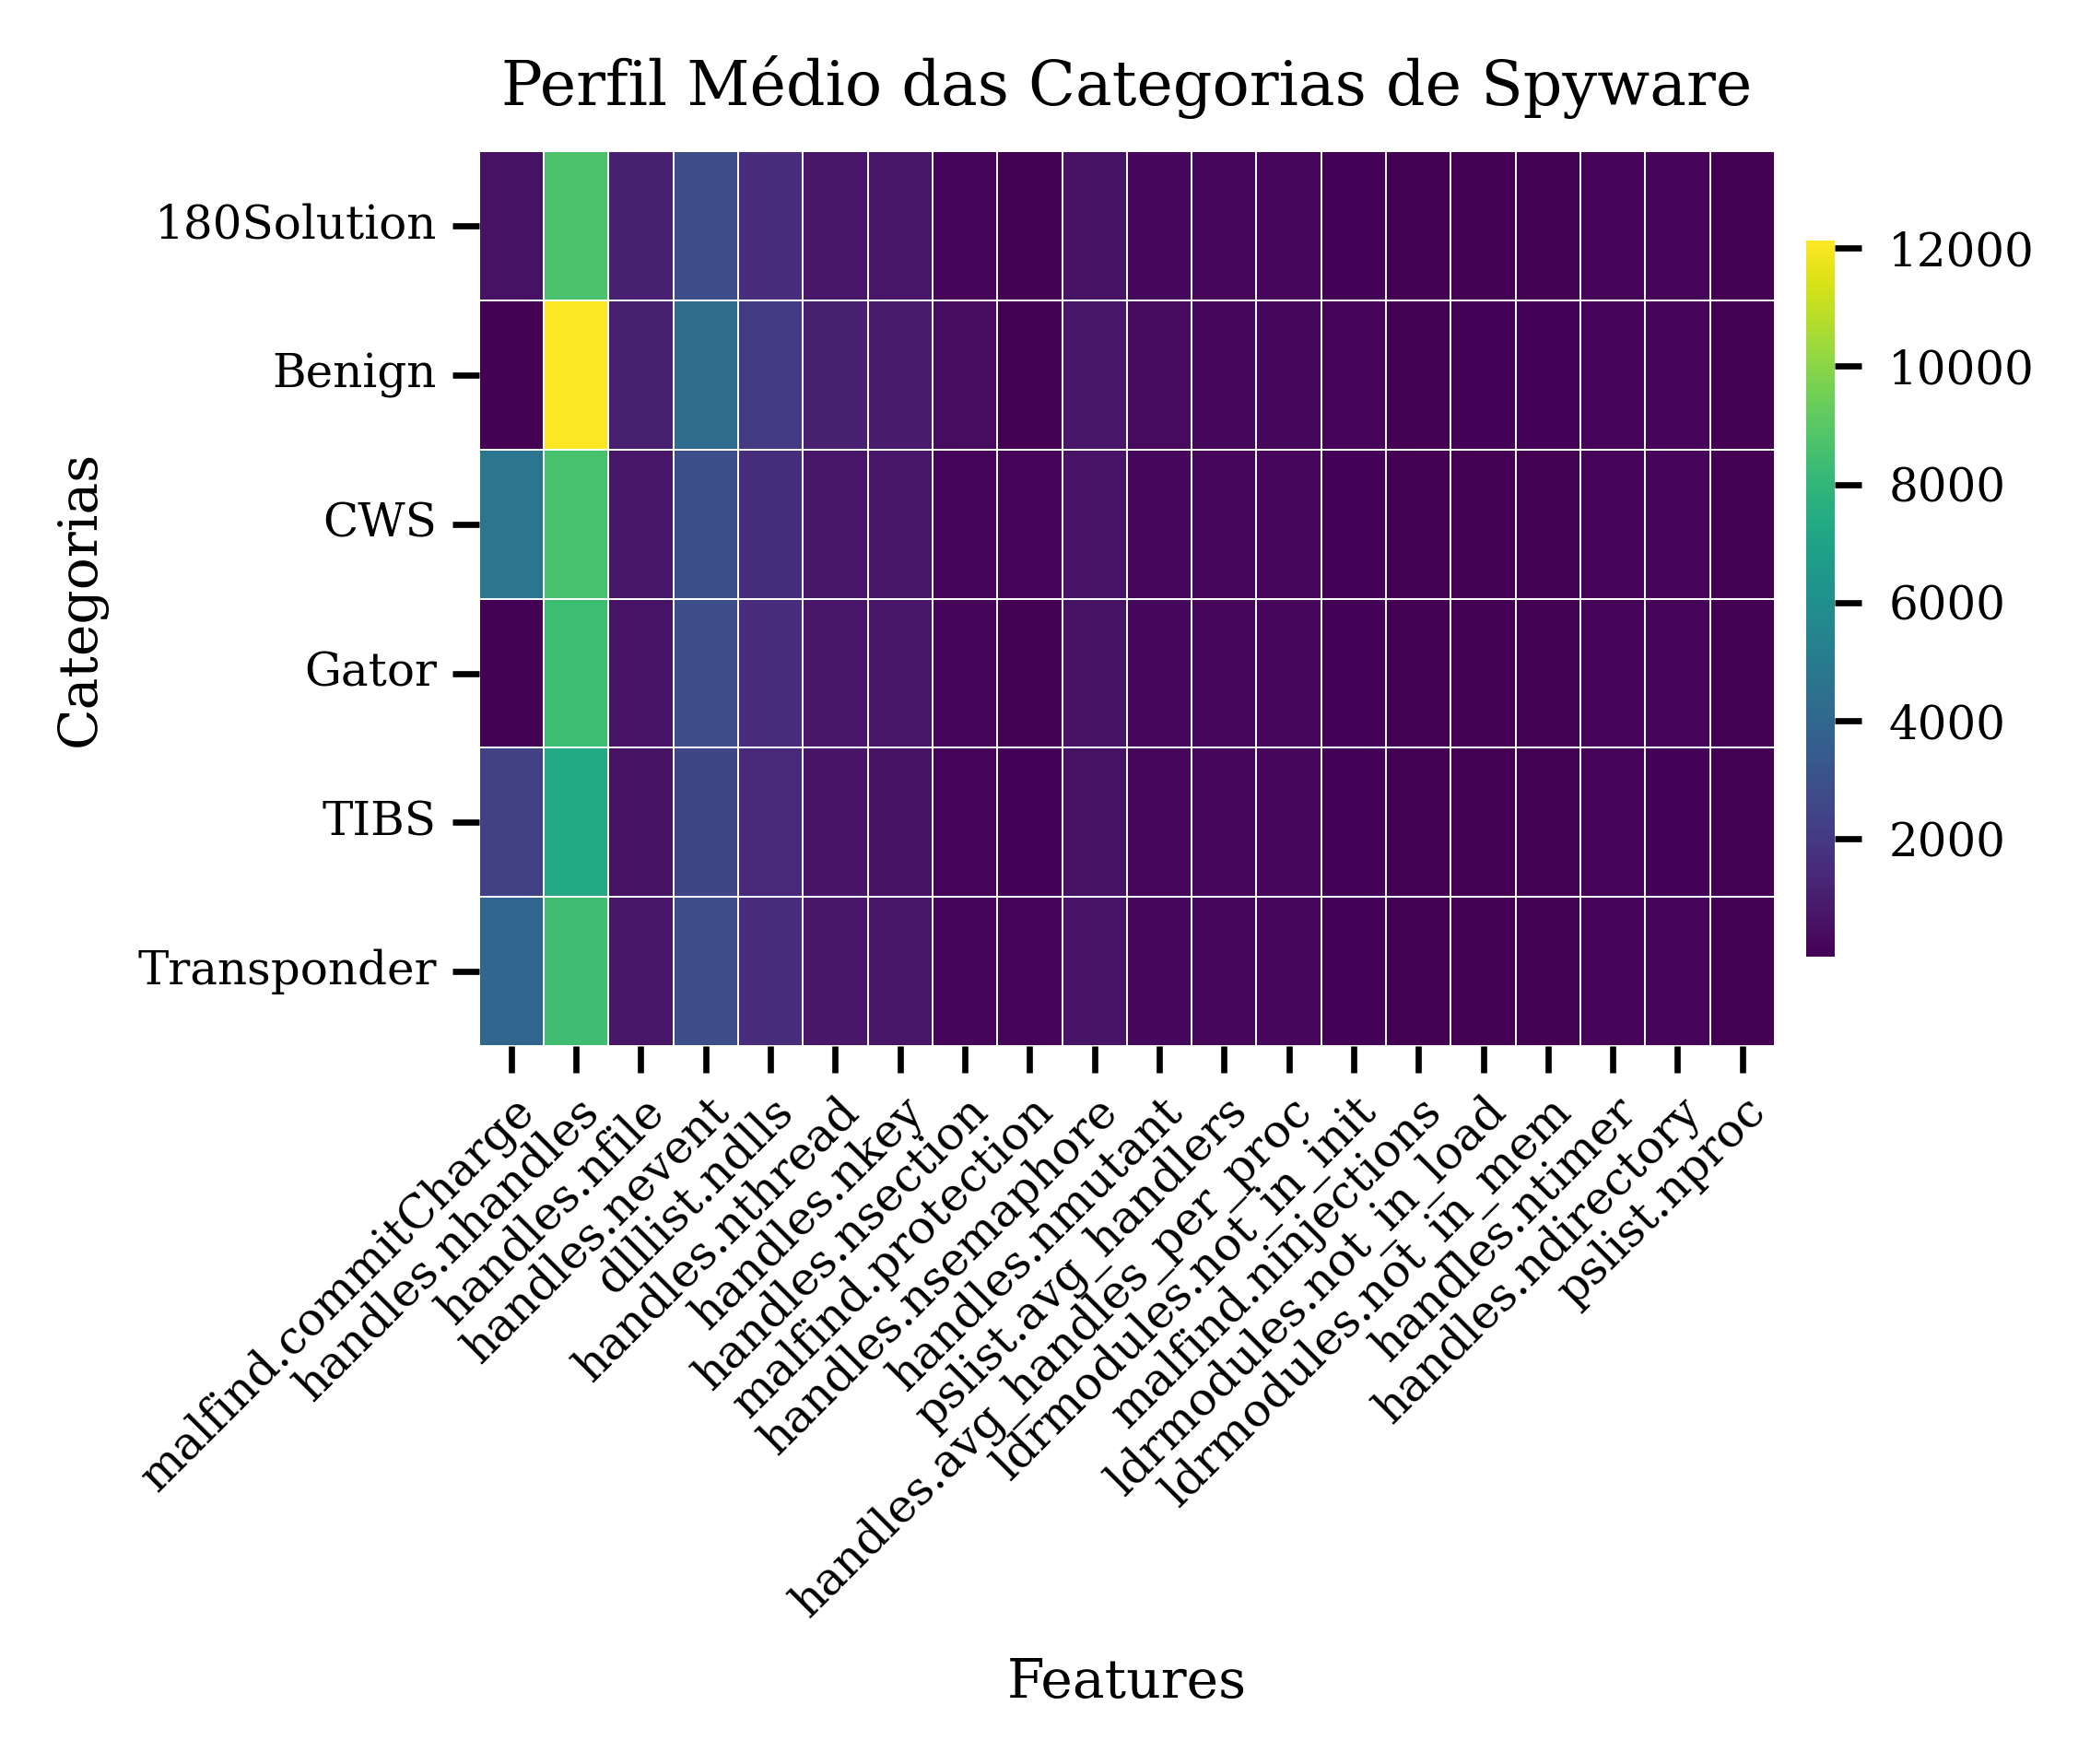

In [ ]:
centroids = (
    dfSpyware
    .groupby("Category")
    .mean(numeric_only=True)
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "figure.dpi": 600
})

fig, ax = plt.subplots(figsize=(3.8, 3.2), dpi=600)

sns.heatmap(
    centroids[top_features],
    cmap="viridis",
    linewidths=0.2,
    cbar_kws={
        "shrink": 0.8,
        "aspect": 25,
        "pad": 0.02
    },
    ax=ax
)

ax.set_title("Perfil Médio das Categorias de Spyware", pad=6)

ax.set_xlabel("Features")
ax.set_ylabel("Categorias")

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(rotation=0)

# Espaçamento leve nos ticks
ax.tick_params(axis='x', pad=2)
ax.tick_params(axis='y', pad=2)

plt.tight_layout()

plt.savefig(
    "Figura_Perfil_Medio_Spyware.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# **Categoria binária**

In [ ]:
dfSpyware = pd.read_csv("dataset_spyware_binary_float32.csv")

In [ ]:
X = dfSpyware.drop(columns=["Category"])
y = dfSpyware["Category"]

X = X.select_dtypes(include=[np.number])

In [ ]:
print("Shape:", dfSpyware.shape)

print("\nNúmero de classes:")
print(y.nunique())

print("\nDistribuição das classes:")
print(y.value_counts())

Shape: (20044, 56)

Número de classes:
2

Distribuição das classes:
Category
0    10022
1    10022
Name: count, dtype: int64


Distribuição das Classes




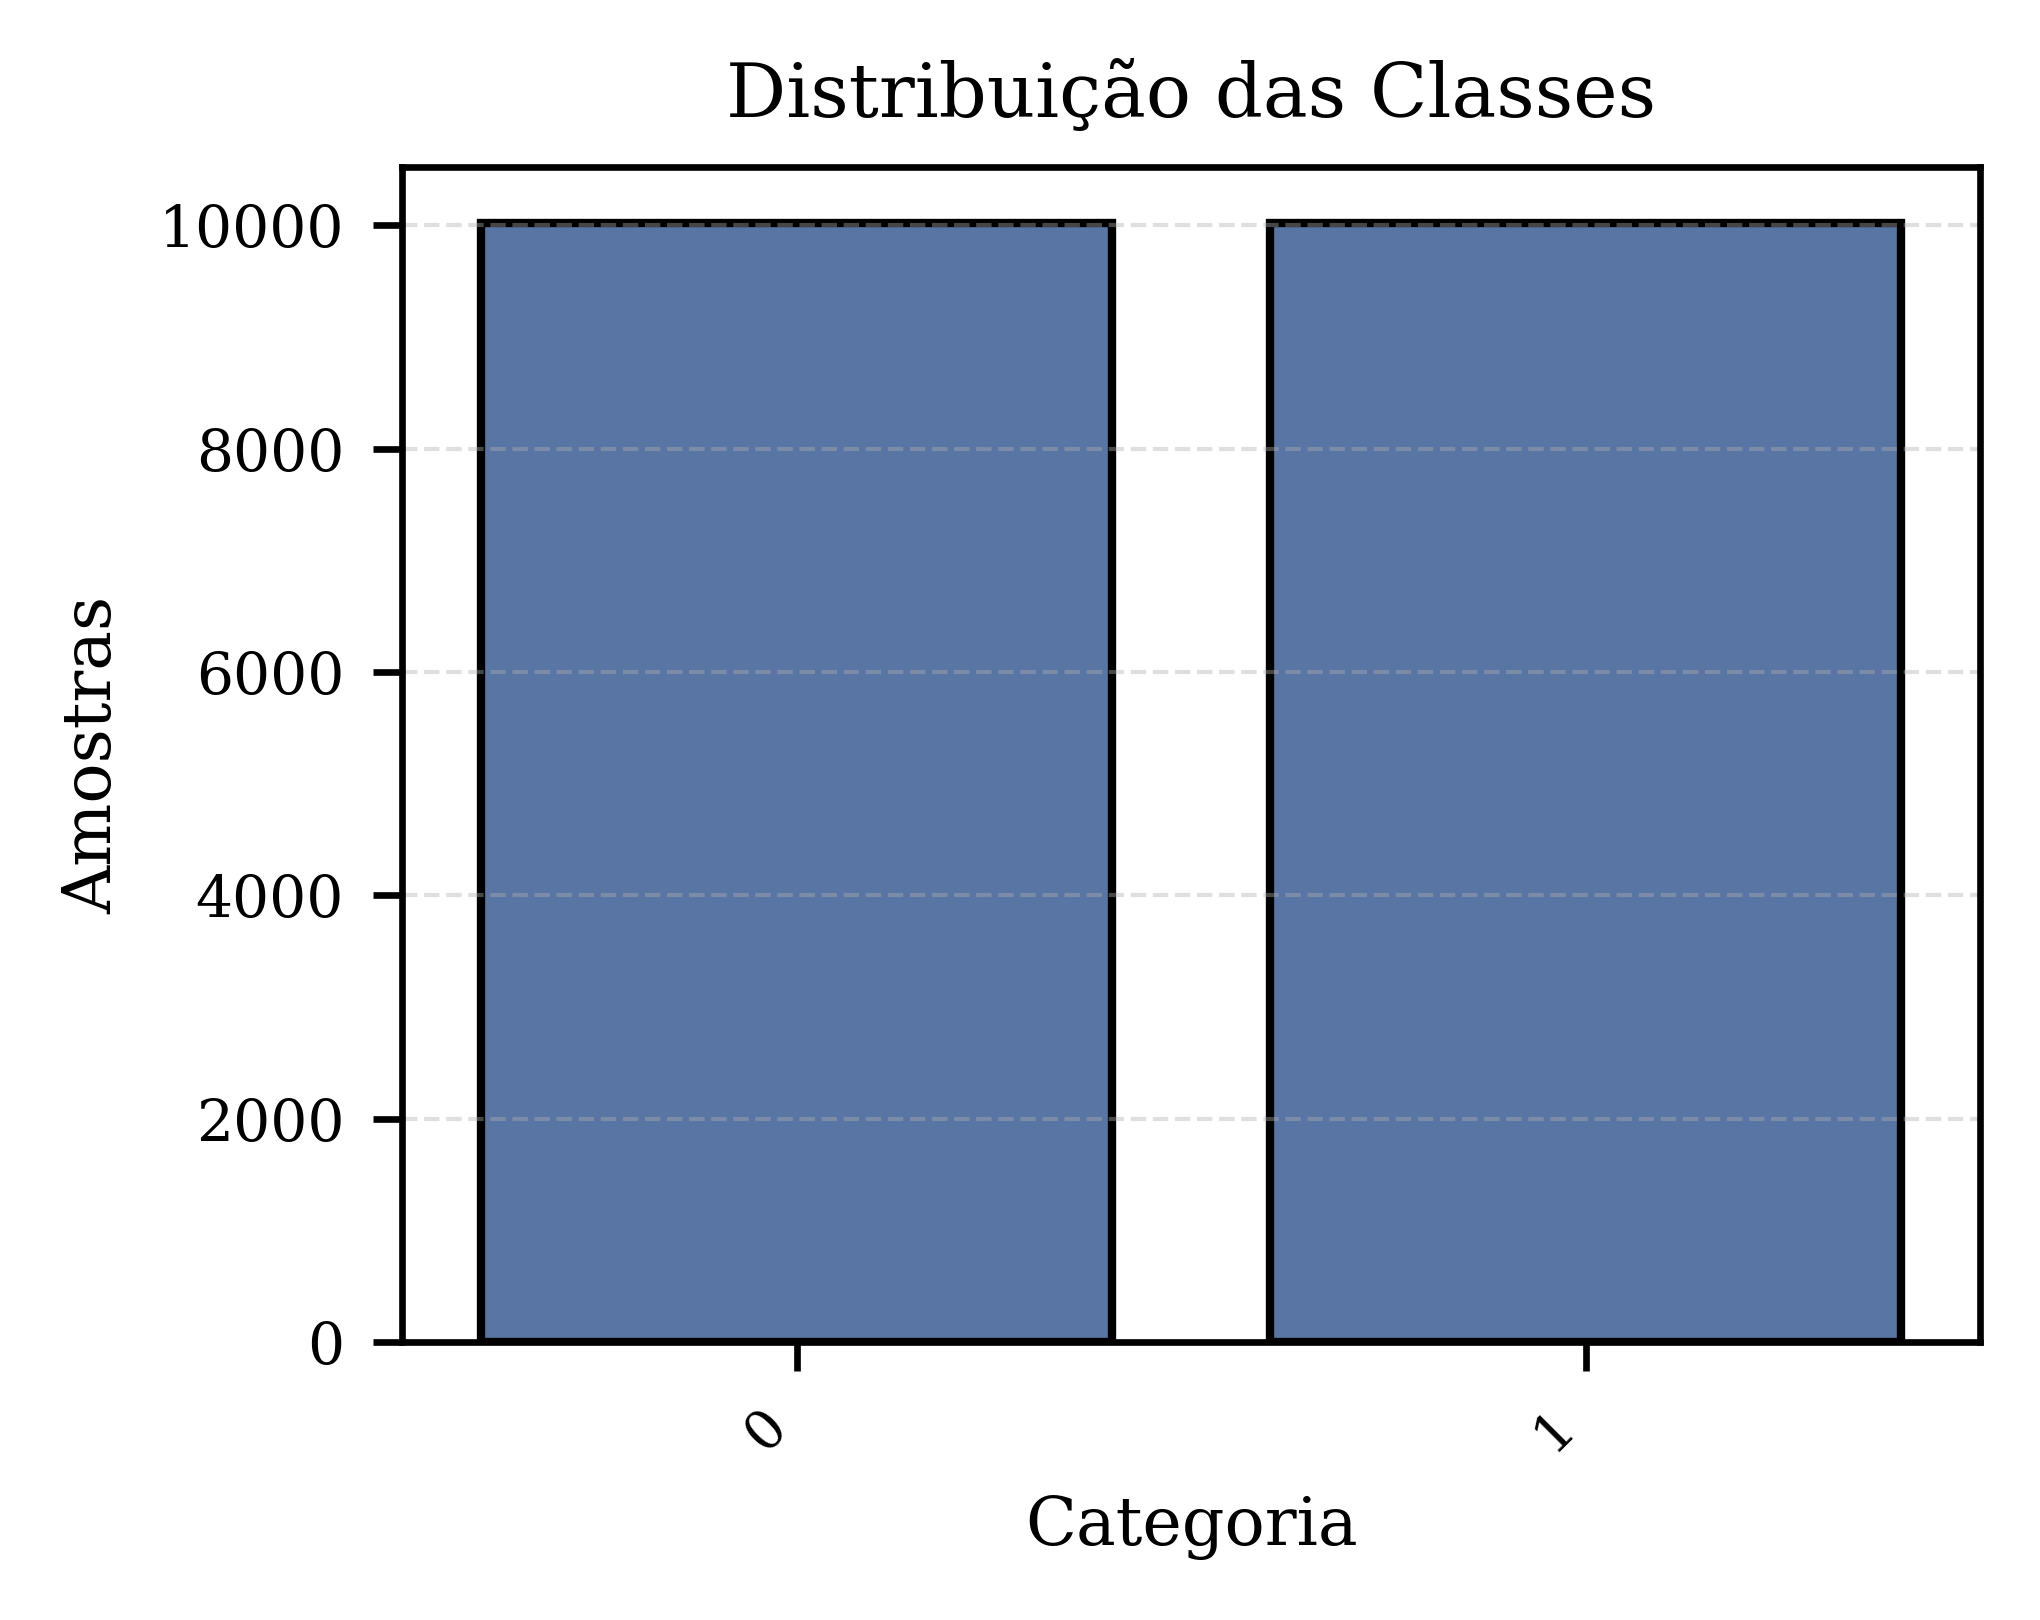

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 7,
    "figure.dpi": 600
})

fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=600)

sns.countplot(
    data=dfSpyware,
    x="Category",
    order=y.value_counts().index,
    color="#4C72B0",
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribuição das Classes", pad=6)
ax.set_xlabel("Categoria")
ax.set_ylabel("Amostras")


plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

plt.tight_layout()

plt.savefig(
    "01_Distribuicao_Classes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Média Agregada

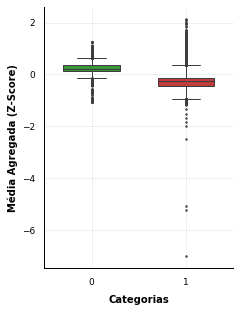

In [ ]:
X = dfSpyware.drop(columns=['Category'])
Y = dfSpyware['Category']

#  Normalização (Z-Score)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Agregação Estatística
df_vis = pd.DataFrame({
    'Score_Medio_Features': X_scaled.mean(axis=1),
    'Class': Y.values
})


sns.set_theme(style="whitegrid")
plt.figure(figsize=(3.5, 4.5))


palette = {
    0: '#2ca02c',
    1: '#d62728'
}

# Plot do Boxplot
ax = sns.boxplot(
    data=df_vis,
    x='Class',
    y='Score_Medio_Features',
    palette=palette,
    dodge=False,
    width=0.6,
    fliersize=1.5,
    linewidth=1.0,
    hue='Class',
    legend=False
)

font_labels = {'color': 'black', 'fontsize': 10, 'weight': 'bold'}
font_ticks = {'color': 'black', 'fontsize': 9}


plt.xlabel('Categorias', fontdict=font_labels, labelpad=8)
plt.ylabel('Média Agregada (Z-Score)', fontdict=font_labels)


plt.xticks(rotation=0, ha='center', **font_ticks)
plt.yticks(**font_ticks)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

ax.tick_params(colors='black', labelsize=9)

ax.grid(
    visible=True,
    linestyle=':',
    linewidth=0.6,
    color='gray',
    alpha=0.5
)


sns.despine(top=True, right=True)
plt.tight_layout()

plt.savefig(
    "BIEEE_Boxplot_Consolidado.png",
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

Features com maior variância

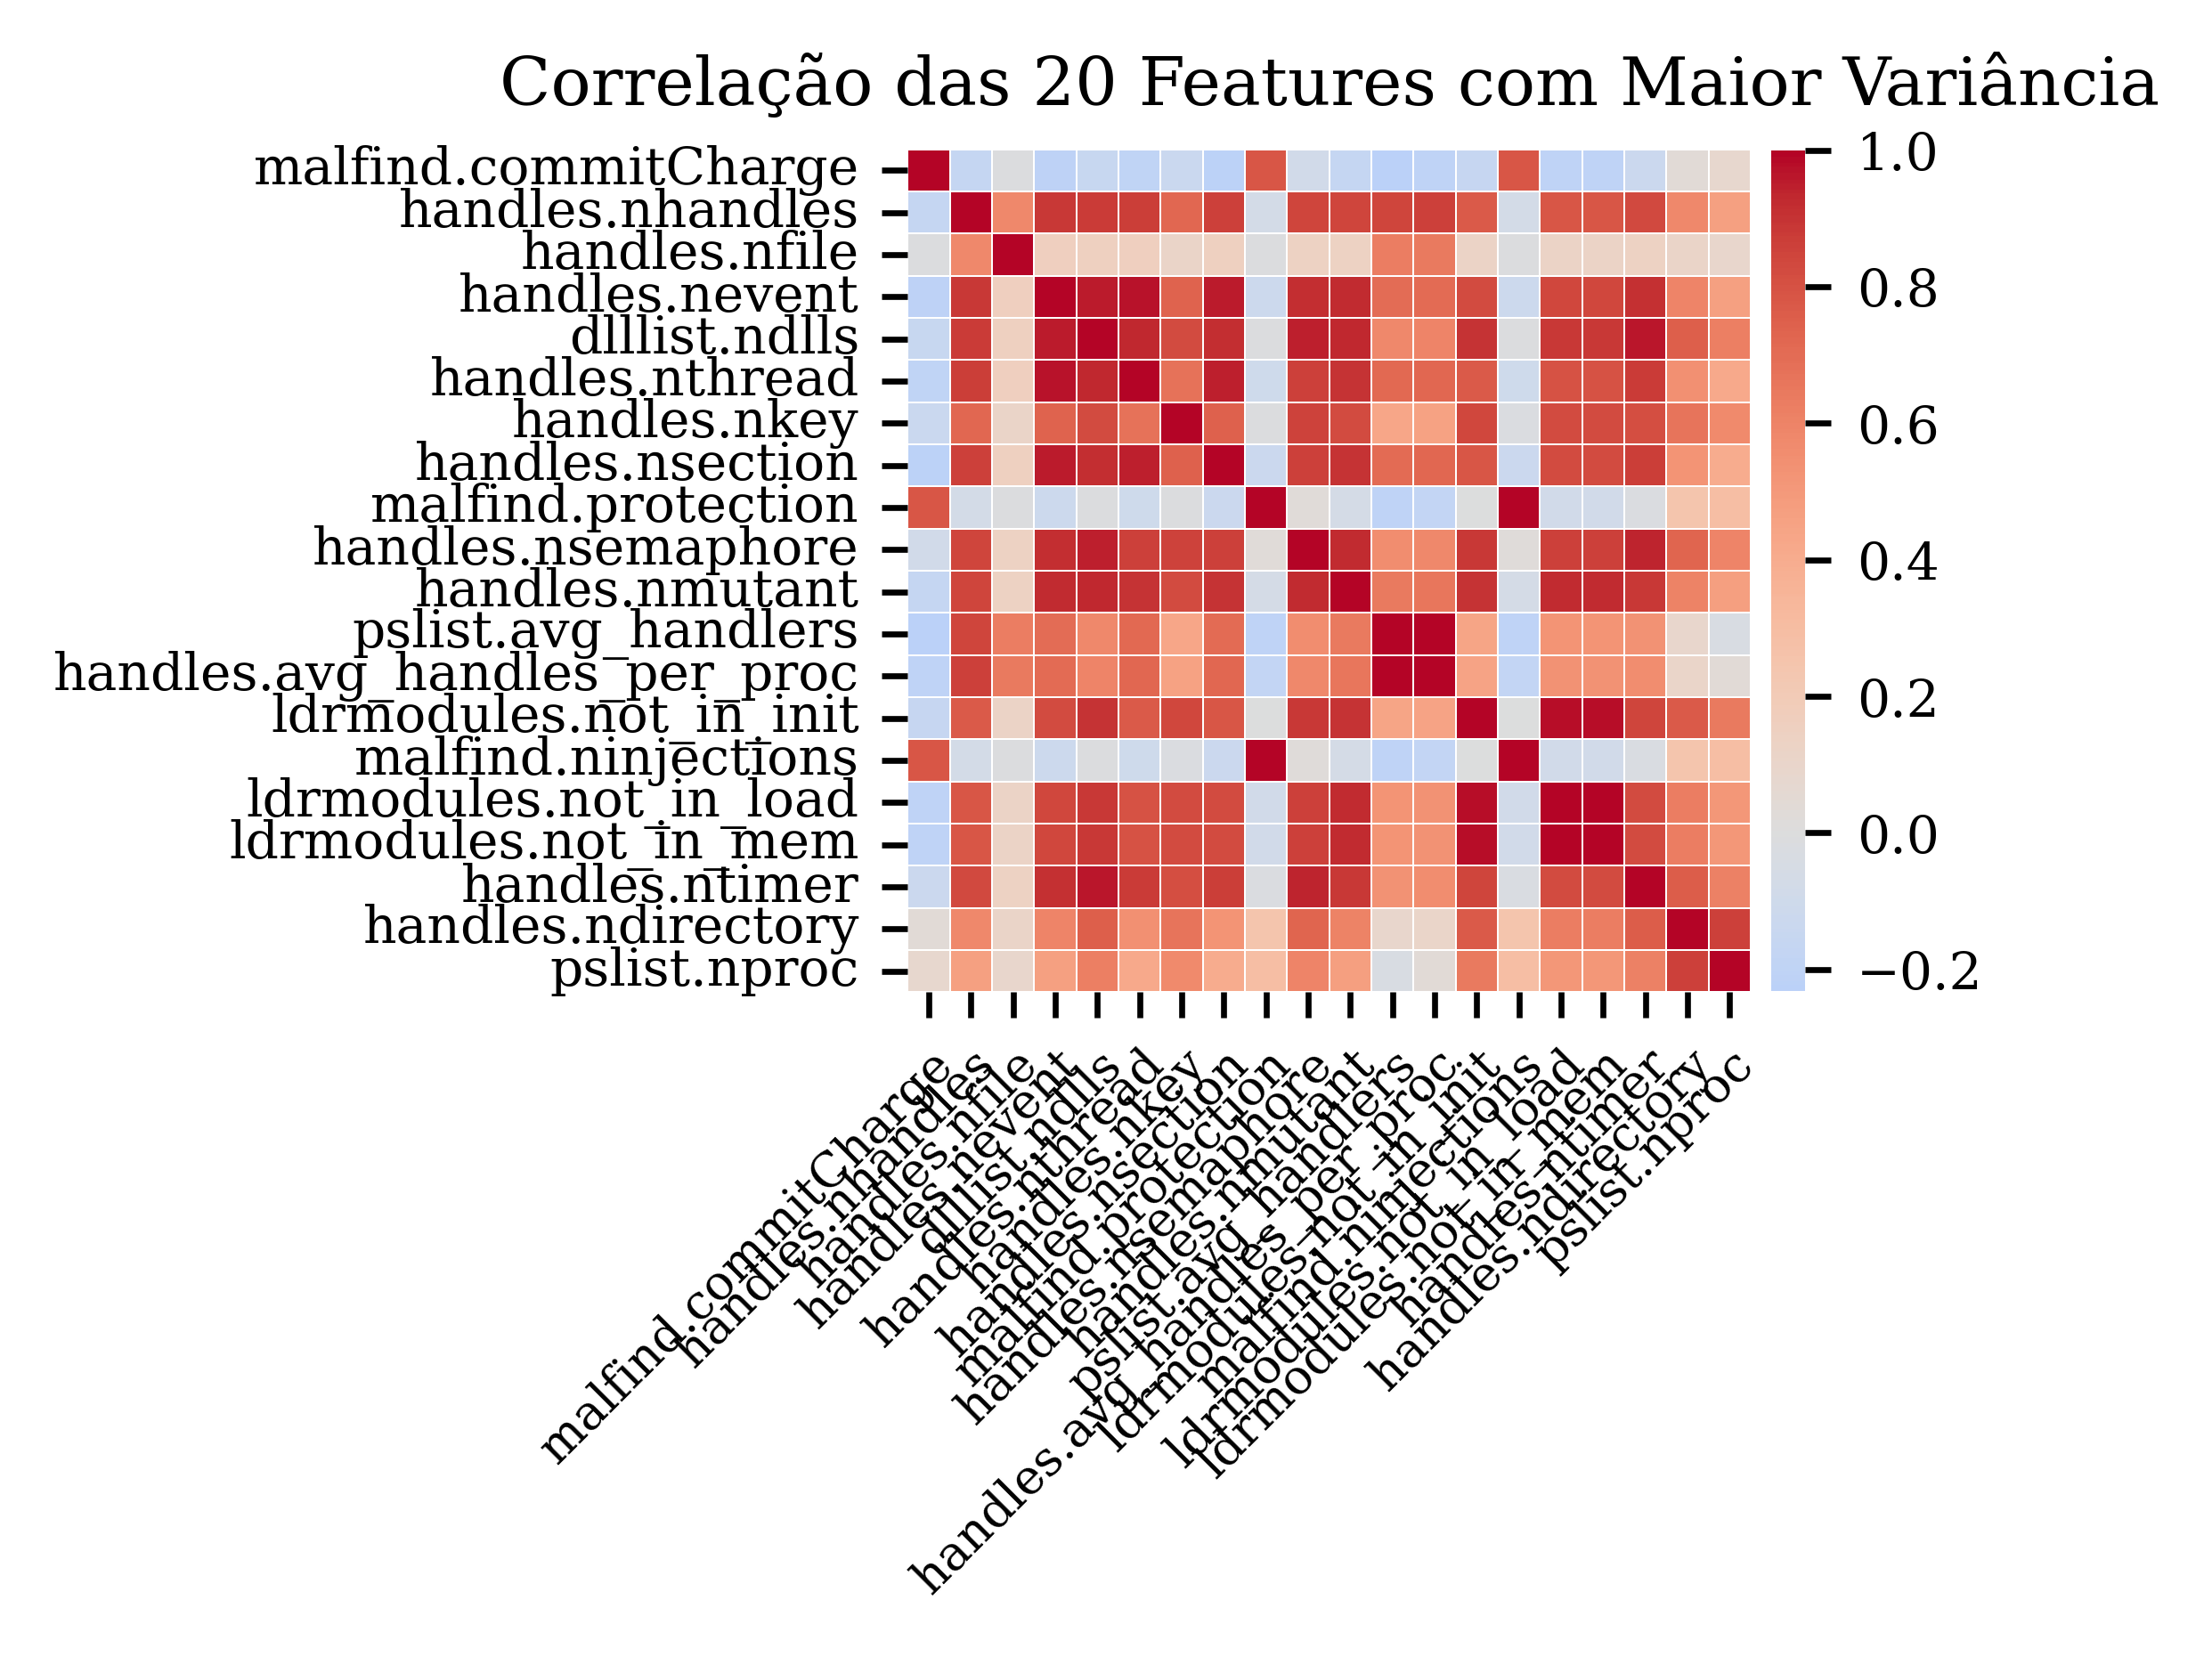

In [ ]:
variancias = X.var()
top_features = variancias.nlargest(20).index
corr = X[top_features].corr()

fig, ax = plt.subplots(figsize=(3.8, 3.6), dpi=600)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={
        "shrink": 0.7,
        "aspect": 25,
        "pad": 0.02
    },
    ax=ax
)

ax.set_title("Correlação das 20 Features com Maior Variância", pad=6)

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(rotation=0)

ax.tick_params(axis='x', pad=3)
ax.tick_params(axis='y', pad=3)

plt.tight_layout()

plt.savefig(
    "01Correlacao_Features.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Perfil médidos das features**

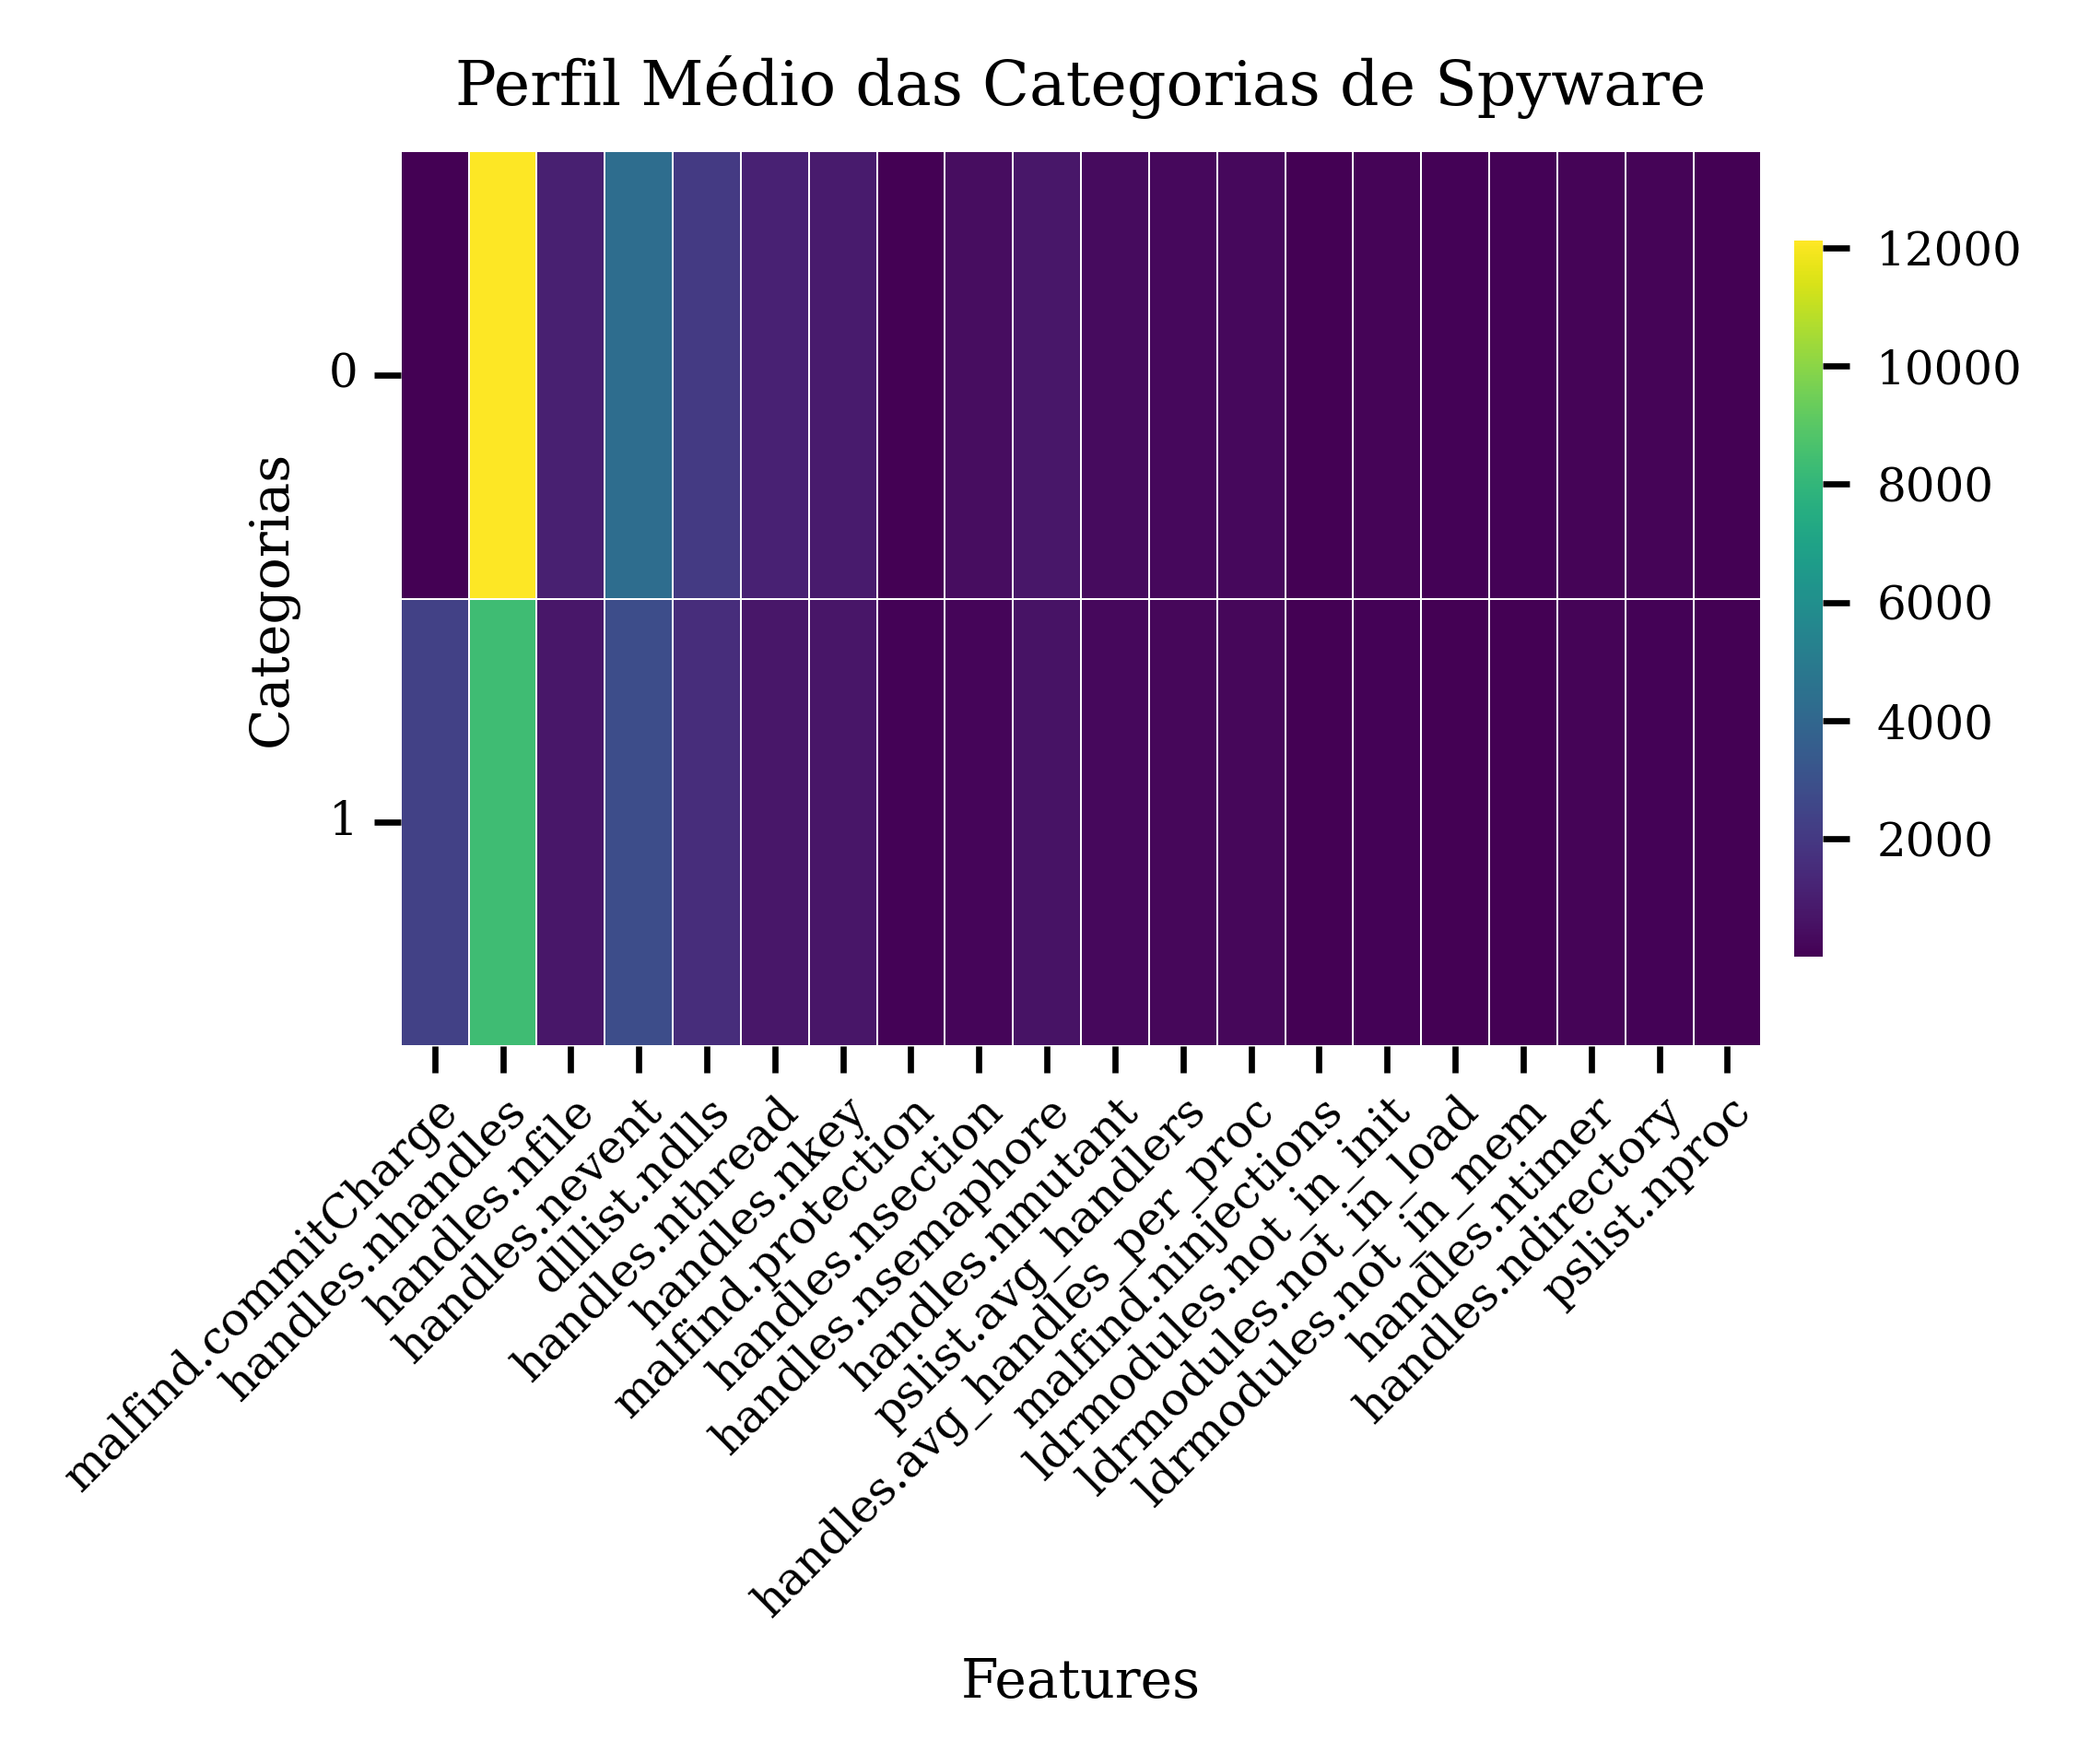

In [ ]:
centroids = (
    dfSpyware
    .groupby("Category")
    .mean(numeric_only=True)
)


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "figure.dpi": 600
})

fig, ax = plt.subplots(figsize=(3.8, 3.2), dpi=600)

sns.heatmap(
    centroids[top_features],
    cmap="viridis",
    linewidths=0.2,
    cbar_kws={
        "shrink": 0.8,
        "aspect": 25,
        "pad": 0.02
    },
    ax=ax
)

ax.set_title("Perfil Médio das Categorias de Spyware", pad=6)

ax.set_xlabel("Features")
ax.set_ylabel("Categorias")

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(rotation=0)

# Espaçamento leve nos ticks
ax.tick_params(axis='x', pad=2)
ax.tick_params(axis='y', pad=2)

plt.tight_layout()

plt.savefig(
    "01_Perfil_Medio_Spyware.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()